<a href="https://colab.research.google.com/github/AnthoniaOffor/ram-egg-classifier/blob/main/CMPT3835_Team_4_Deployment_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#0.0 Team Name : Nest Best Thing
Team 4 Members : Anthonia Offor

Augusto R. Menegasse

Ayomide Tubi

Navodhi Ranatunga

#1.0 Install dependencies (same as Hugging Face)

In [1]:
!pip install -q ultralytics shap gradio opencv-python matplotlib torch numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 13.4 MB/s eta 0:00:00


#2.0 Mount Google Drive

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


#3.0 Load YOLOv8 model (best.pt)

In [4]:
from ultralytics import YOLO
import os

MODEL_PATH = "/content/drive/MyDrive/best.pt"

assert os.path.exists(MODEL_PATH), "best.pt not found"
model = YOLO(MODEL_PATH)

print(" YOLO model loaded")
print("Classes:", model.names)

 YOLO model loaded
Classes: {0: 'Agelaius_phoeniceus', 1: 'Ammodramus_savannarum', 2: 'Anthus_spinoletta', 3: 'Cardellina_pusilla', 4: 'Certhia_americana', 5: 'Cistothorus_palustris', 6: 'Euphagus_cyanocephalus', 7: 'Geothlypis_tolmiei', 8: 'Geothlypis_trichas', 9: 'Icteria_virens', 10: 'Junco_hyemalis', 11: 'Molothrus_ater', 12: 'Passer_domesticus', 13: 'Passerella_iliaca', 14: 'Poecile_atricapillus', 15: 'Pooecetes_gramineus', 16: 'Quiscalus_quiscula', 17: 'Setophaga_petechia', 18: 'Setophaga_ruticilla', 19: 'Vireo_olivaceus', 20: 'Zonotrichia_albicollis'}


#4.0 Core prediction + SHAP function (APP LOGIC)

This section combines prediction and explanation into one function. It detects the egg, predicts the species, crops the detected egg, and then generates a SHAP explanation for the model’s decision.

In [5]:

import cv2
import numpy as np
import torch
import shap
import matplotlib.pyplot as plt

def predict_and_explain(image, show_plot=True):
    """
    image: numpy array (H, W, 3)
    returns: species, confidence
    """

    # Run YOLO quietly
    result = model.predict(image, verbose=False)[0]
    boxes = result.boxes

    if boxes is None or len(boxes) == 0:
        print("No egg detected")
        return "No egg detected", "N/A"

    idx = torch.argmax(boxes.conf).item()
    species_id = int(boxes.cls[idx].item())
    species = model.names[species_id]
    confidence = float(boxes.conf[idx].item())

    box = boxes.xyxy[idx].int().tolist()
    crop = image[box[1]:box[3], box[0]:box[2]]

    if crop.size == 0:
        print("Empty crop")
        return species, f"{confidence:.2f}"

    egg = cv2.resize(crop, (128, 128)).astype(np.float32) / 255.0
    TARGET_CLASS_ID = species_id

    def yolo_score(images):
        if images.ndim == 3:
            images = images[np.newaxis, ...]

        device = next(model.model.parameters()).device
        outputs = []

        model.model.eval()
        with torch.no_grad():
            for img in images:
                img = np.asarray(img, dtype=np.float32)
                x = torch.from_numpy(img).permute(2, 0, 1).unsqueeze(0).to(device)

                preds = model.model(x)[0]
                class_logits = preds[..., -model.model.nc:]
                probs = class_logits.sigmoid()
                scores = probs[..., TARGET_CLASS_ID]
                outputs.append(scores.max().item())

        return np.array(outputs)

    masker = shap.maskers.Image("inpaint_telea", egg.shape)
    explainer = shap.Explainer(yolo_score, masker)
    shap_values = explainer(egg[np.newaxis, ...], max_evals=200)

    if show_plot:
        plt.close("all")
        shap.image_plot(shap_values, egg[np.newaxis, ...], show=False)
        fig = plt.gcf()
        plt.show()
        plt.close(fig)

    return species, f"{confidence:.2f}"

#5.0 Simulate client upload(Test)

This section simulates how a user image would be uploaded into the application. It loads a test image and prepares it in the same format the app would receive from a real client.

In [6]:
#Unzip Dataset
import zipfile
import os

ZIP_PATH = "/content/drive/MyDrive/Final_DS.zip"
EXTRACT_PATH = "/content/client_test_images"

if not os.path.exists(EXTRACT_PATH):
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(EXTRACT_PATH)

print(" Test images extracted to:", EXTRACT_PATH)

 Test images extracted to: /content/client_test_images


In [7]:
from PIL import Image
import numpy as np

# Pick any image you want to test with
TEST_IMAGE_PATH = "/content/client_test_images/Train_images/Icteria_Virens_029.jpg"

assert os.path.exists(TEST_IMAGE_PATH), "Test image not found"

# This line simulates what Gradio will send to the app
client_uploaded_image = np.array(
    Image.open(TEST_IMAGE_PATH).convert("RGB")
)

print(" Simulated client upload ready:", client_uploaded_image.shape)

 Simulated client upload ready: (640, 640, 3)


## 5.1 Single image test

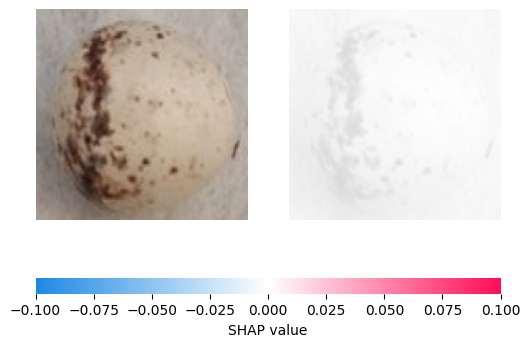

Predicted species: Ammodramus_savannarum
Confidence: 0.27


In [ ]:
species, confidence = predict_and_explain(client_uploaded_image, show_plot=True)

print("Predicted species:", species)
print("Confidence:", confidence)


## 5.2 Loop to test multiple images

This section tests the prediction and explanation pipeline on multiple images to confirm that the workflow runs correctly across different examples.


Testing: Icteria_Virens_083.jpg


  0%|          | 0/198 [00:00<?, ?it/s]

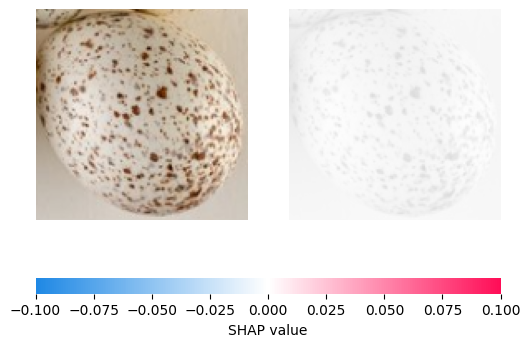

Predicted species: Certhia_americana
Confidence: 0.81

Testing: eb7d37c3-Ammodramus_savannarum_001.jpeg


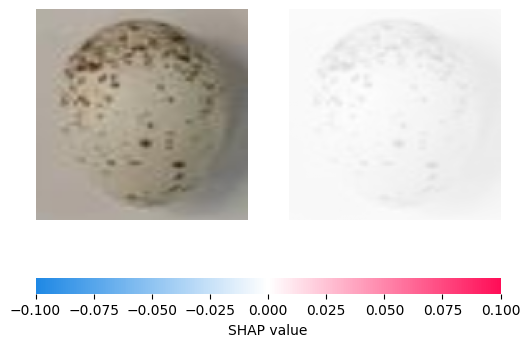

Predicted species: Passerella_iliaca
Confidence: 0.47

Testing: 1e4177bb-Poecile_atricapillus038.jpg


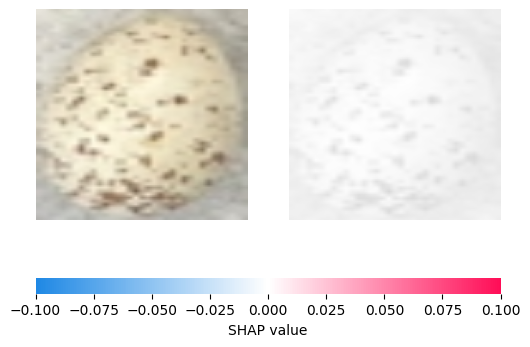

Predicted species: Poecile_atricapillus
Confidence: 0.95


In [ ]:
test_images = [
    "Icteria_Virens_083.jpg",
    "eb7d37c3-Ammodramus_savannarum_001.jpeg",
    "1e4177bb-Poecile_atricapillus038.jpg"
]

for fname in test_images:
    path = os.path.join(EXTRACT_PATH, "Val_images", fname)
    print(f"\nTesting: {fname}")

    image = cv2.imread(path)
    if image is None:
        print(f"Could not load: {path}")
        continue

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    species, confidence = predict_and_explain(image, show_plot=True)

    print("Predicted species:", species)
    print("Confidence:", confidence)

In [8]:
os.listdir("/content/client_test_images")

['Val_labels', 'Test', 'Val_images', 'Train_images', 'Train_Labels']


Testing: Icteria_Virens_029.jpg


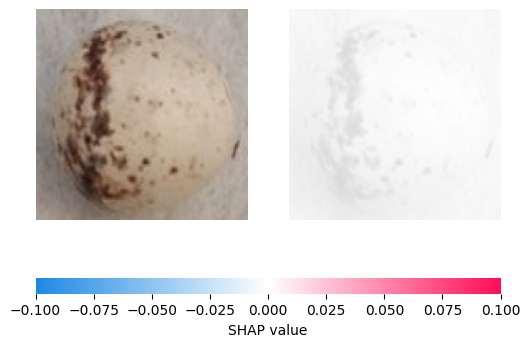

Predicted species: Ammodramus_savannarum
Confidence: 0.27

Testing: Geothlypis_Trichas_001.jpg


  0%|          | 0/198 [00:00<?, ?it/s]

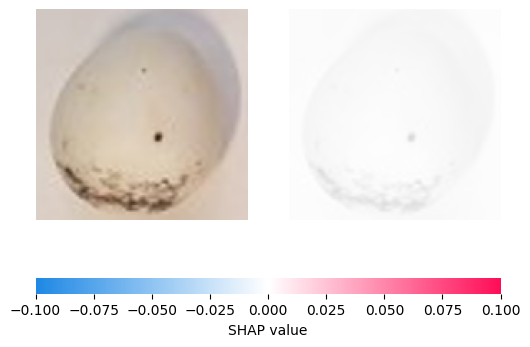

Predicted species: Pooecetes_gramineus
Confidence: 0.73

Testing: Junco_Hyemalis_001.jpg


  0%|          | 0/198 [00:00<?, ?it/s]

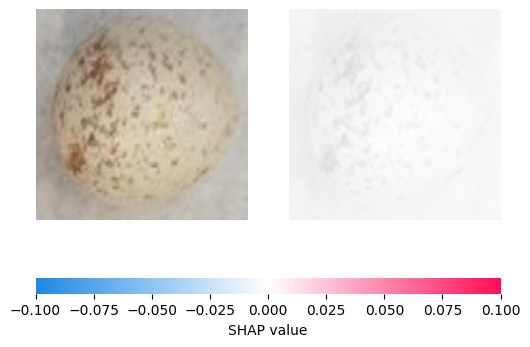

Predicted species: Junco_hyemalis
Confidence: 0.95


In [9]:
import os
import cv2

test_images = [
    "Icteria_Virens_029.jpg",
    "Geothlypis_Trichas_001.jpg",
    "Junco_Hyemalis_001.jpg"
]

folder = "/content/client_test_images/Train_images"

for fname in test_images:
    path = os.path.join(folder, fname)
    print(f"\nTesting: {fname}")

    if not os.path.exists(path):
        print(f"Missing file: {path}")
        continue

    image = cv2.imread(path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    species, confidence = predict_and_explain(image, show_plot=True)

    print("Predicted species:", species)
    print("Confidence:", confidence)

Let’s interpret your three cases one by one
Case 1: Icteria_Virens_029.jpg

Predicted species: Ammodramus_savannarum
Confidence: 0.27 (low)

What this means

The model was uncertain
The egg shares visual traits with multiple species
The model picked the closest match, but without strong confidence


Case 2: Geothlypis_Trichas_001.jpg

Predicted species: Pooecetes_gramineus
Confidence: ~0.73 (moderate)

What this means

The model saw some supporting evidence
But egg features still overlap across species
SHAP remains subtle, not concentrated

Case 3: Junco_Hyemalis_001.jpg

Predicted species: Junco hyemalis
Confidence: 0.95 (high)

What this means

Clear, distinctive egg features
Strong match to training patterns
SHAP agrees (still subtle, but consistent)

The faint SHAP map supports this:
there is no strong visual evidence pushing one species.



Although filenames provide ground‑truth species labels, the model bases its predictions solely on visual appearance. Bird eggs from different species often share similar color and speckling patterns, which can lead to visually plausible but biologically incorrect predictions. In such cases, the model may predict an alternative species with moderate confidence. SHAP explanations correctly reflect this uncertainty by showing weak or diffuse pixel contributions, indicating the absence of strong visual evidence for a single species.

#6.0 Create requirements.txt
 This is required for deployment

In [10]:
%%writefile requirements.txt
ultralytics
torch
opencv-python
numpy
shap
matplotlib
gradio

Writing requirements.txt


In [11]:
!cat requirements.txt

ultralytics
torch
opencv-python
numpy
shap
matplotlib
gradio


#7.0 Create app.py (this is the deployed app)

In [12]:
import cv2
import numpy as np
import torch
import shap
import matplotlib.pyplot as plt
import gradio as gr
import io
from PIL import Image
from ultralytics import YOLO


# ----------------------------
# Load YOLOv8 model
# ----------------------------
model = YOLO("/content/drive/MyDrive/best.pt")


# ----------------------------
# Prediction + SHAP function
# ----------------------------
def predict_and_explain(image):
    """
    image: numpy array (H, W, 3) from Gradio upload
    returns:
      - predicted species (str)
      - confidence score (str)
      - SHAP explanation image (PIL.Image or None)
    """

    # Run YOLO inference
    result = model.predict(image, verbose=False)[0]
    boxes = result.boxes

    # No detection case
    if boxes is None or len(boxes) == 0:
        return "No egg detected", "N/A", None

    # Select highest-confidence detection
    idx = torch.argmax(boxes.conf).item()
    species_id = int(boxes.cls[idx].item())
    species = model.names[species_id]
    confidence = float(boxes.conf[idx].item())

    # Crop detected egg
    box = boxes.xyxy[idx].int().tolist()
    crop = image[box[1]:box[3], box[0]:box[2]]

    if crop.size == 0:
        return species, f"{confidence:.2f}", None

    # Prepare egg image for SHAP
    egg = cv2.resize(crop, (128, 128)).astype(np.float32) / 255.0
    TARGET_CLASS_ID = species_id


    # ----------------------------
    # YOLO confidence function for SHAP
    # ----------------------------
    def yolo_score(images):
        if images.ndim == 3:
            images = images[np.newaxis, ...]

        scores = []
        model.model.eval()

        with torch.no_grad():
            for img in images:
                x = torch.from_numpy(img).permute(2, 0, 1).unsqueeze(0).float()
                preds = model.model(x)[0]
                probs = preds[..., -model.model.nc:].sigmoid()
                scores.append(probs[..., TARGET_CLASS_ID].max().item())

        return np.array(scores)


    # ----------------------------
    # SHAP explanation
    # ----------------------------
    masker = shap.maskers.Image("inpaint_telea", egg.shape)
    explainer = shap.Explainer(yolo_score, masker)

    shap_values = explainer(
        egg[np.newaxis, ...],
        max_evals=200
    )

    # Convert SHAP plot to image for Gradio
    plt.close("all")
    shap.image_plot(shap_values, egg[np.newaxis, ...], show=False)

    buf = io.BytesIO()
    plt.savefig(buf, format="png", bbox_inches="tight")
    plt.close()
    buf.seek(0)

    shap_image = Image.open(buf)

    return species, f"{confidence:.2f}", shap_image


# ----------------------------
# Gradio Interface
# ----------------------------
demo = gr.Interface(
    fn=predict_and_explain,
    inputs=gr.Image(type="numpy", label="Upload Egg Image"),
    outputs=[
        gr.Text(label="Predicted Species"),
        gr.Text(label="Confidence Score"),
        gr.Image(label="SHAP Explanation"),
    ],
    title="Nest Best Thing (Explainable AI)",
    description=(
        "Upload an image of a bird egg. "
        "The model predicts the species, provides a confidence score, "
        "and explains the prediction using SHAP."
    )
)


# ----------------------------
# Launch app
# ----------------------------
demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c20bcc08102ef06216.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


#8.0 Application Deployment - app.py

In [13]:
%%writefile app.py
import cv2
import numpy as np
import torch
import shap
import matplotlib.pyplot as plt
import gradio as gr
import io
from PIL import Image
from ultralytics import YOLO

# Load model
model = YOLO("best.pt")

def predict_and_explain(image):
    result = model.predict(image, verbose=False)[0]
    boxes = result.boxes

    if boxes is None or len(boxes) == 0:
        return "No egg detected", "N/A", None

    idx = torch.argmax(boxes.conf).item()
    species_id = int(boxes.cls[idx].item())
    species = model.names[species_id]
    confidence = float(boxes.conf[idx].item())

    box = boxes.xyxy[idx].int().tolist()
    crop = image[box[1]:box[3], box[0]:box[2]]

    if crop.size == 0:
        return species, f"{confidence:.2f}", None

    egg = cv2.resize(crop, (128, 128)).astype(np.float32) / 255.0
    TARGET_CLASS_ID = species_id

    def yolo_score(images):
        if images.ndim == 3:
            images = images[np.newaxis, ...]
        outputs = []
        model.model.eval()
        with torch.no_grad():
            for img in images:
                x = torch.from_numpy(img).permute(2,0,1).unsqueeze(0).float()
                preds = model.model(x)[0]
                probs = preds[..., -model.model.nc:].sigmoid()
                outputs.append(probs[..., TARGET_CLASS_ID].max().item())
        return np.array(outputs)

    masker = shap.maskers.Image("inpaint_telea", egg.shape)
    explainer = shap.Explainer(yolo_score, masker)
    shap_values = explainer(egg[np.newaxis, ...], max_evals=200)

    plt.close("all")
    shap.image_plot(shap_values, egg[np.newaxis, ...], show=False)
    buf = io.BytesIO()
    plt.savefig(buf, format="png", bbox_inches="tight")
    plt.close()
    buf.seek(0)
    shap_image = Image.open(buf)

    return species, f"{confidence:.2f}", shap_image

demo = gr.Interface(
    fn=predict_and_explain,
    inputs=gr.Image(type="numpy", label="Upload Egg Image"),
    outputs=[
        gr.Text(label="Predicted Species"),
        gr.Text(label="Confidence Score"),
        gr.Image(label="SHAP Explanation"),
    ],
    title="Nest Best Thing (Explainable AI)",
    description="Upload an egg image to predict the species and view a SHAP explanation."
)

demo.launch()

Writing app.py


In [14]:
!ls

app.py	best.pt  client_test_images  drive  requirements.txt  sample_data


In [17]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 67.1 MB/s eta 0:00:00


In [ ]:
!streamlit run app.py



2026-06-05 01:20:51.888 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.138.175.39:8501

